## Convolutional autoencoder for Fashion MNIST dataset

### Imports

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


### Get the data

We will use the Fashion MNIST dataset

In [2]:
# Scale image to [0,1] range
transform = transforms.ToTensor()

train_ds = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_ds = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

batch_size = 100
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=batch_size, shuffle=True)

# Extract to torch tensor
X_train, y_train = next(iter(train_dl))

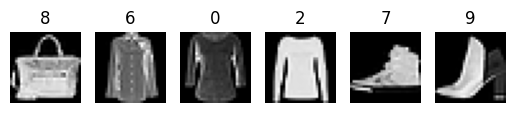

In [3]:
# Inspect a few figures
fig, axs = plt.subplots(1, 6)
for i, ax in enumerate(axs):
    idx = np.random.randint(len(X_train))
    ax.imshow(X_train[idx][0], cmap="gray")
    ax.set_title(y_train[idx].item())
    ax.axis("off")

### Define the model

In [4]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim: int = 16) -> None:
        super().__init__()

        self.latent_dim: int = latent_dim

        # Encoder
        self.encoder: nn.Sequential = nn.Sequential(
            nn.Conv2d(
                in_channels=1, out_channels=16, kernel_size=3, stride=2, padding=1
            ),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, self.latent_dim),
        )

        # Decoder
        self.decoder: nn.Sequential = nn.Sequential(
            nn.Linear(self.latent_dim, 32 * 7 * 7),
            nn.ReLU(),
            nn.Unflatten(1, (32, 7, 7)),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )
        return

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out, z
    
model = Autoencoder(latent_dim=16).to(device)

And prepare the optimisers and lossess

In [5]:
optimiser = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

### Run!

In [7]:
n_epochs = 10
for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for images, _ in train_dl:
        images = images.to(device)
        rec, _ = model(images)
        loss = criterion(rec, images)

        optimiser.zero_grad()
        loss.backward()
        optimiser.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{n_epochs}, loss: {total_loss/len(train_dl):.4f}")

Epoch 1/10, loss: 0.0303
Epoch 2/10, loss: 0.0162
Epoch 3/10, loss: 0.0145
Epoch 4/10, loss: 0.0136
Epoch 5/10, loss: 0.0130
Epoch 6/10, loss: 0.0126
Epoch 7/10, loss: 0.0122
Epoch 8/10, loss: 0.0120
Epoch 9/10, loss: 0.0118
Epoch 10/10, loss: 0.0116


### Compare reconstructed with original

Text(0, 0.5, 'reconstructed')

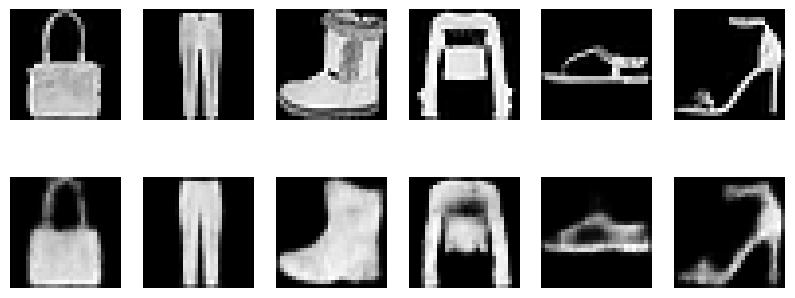

In [8]:
model.eval()
images, _ = next(iter(test_dl))
images = images.to(device)
with torch.no_grad():
    recon, _ = model(images)

fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for i in range(6):
    axes[0, i].imshow(images[i][0].cpu(), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(recon[i][0].cpu(), cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("original")
axes[1, 0].set_ylabel("reconstructed")

### Latent representation

In [16]:
model.eval()

all_latents = []
all_labels = []

with torch.no_grad():
    for images, labels in test_dl:
        images = images.to(device)
        _, z = model(images)
        all_latents.append(z.cpu().numpy())
        all_labels.append(labels.numpy())

all_latents = np.concatenate(all_latents)
all_labels = np.concatenate(all_labels)
# Standard scale latents just in case
all_latents = StandardScaler().fit_transform(all_latents)
print(all_latents.shape)

(10000, 16)


### K-means and PCA visualisation

In [17]:
kmeans = KMeans(n_clusters=10, n_init=10)
clusters_ids = kmeans.fit_predict(all_latents)

pca = PCA(n_components=2)
latents_2d = pca.fit_transform(all_latents)

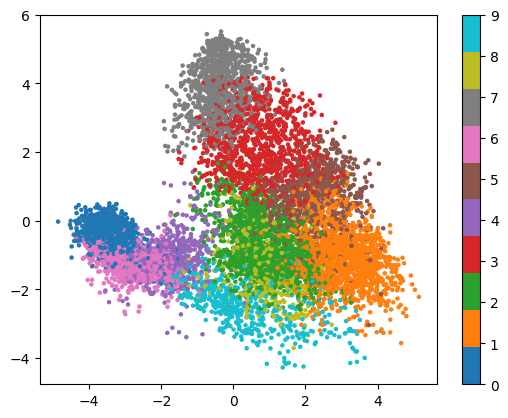

In [18]:
fig, ax = plt.subplots()
scatter = ax.scatter(latents_2d[:, 0], latents_2d[:, 1], c=clusters_ids, s=5, cmap="tab10")
fig.colorbar(scatter)

### TSNE visualisation

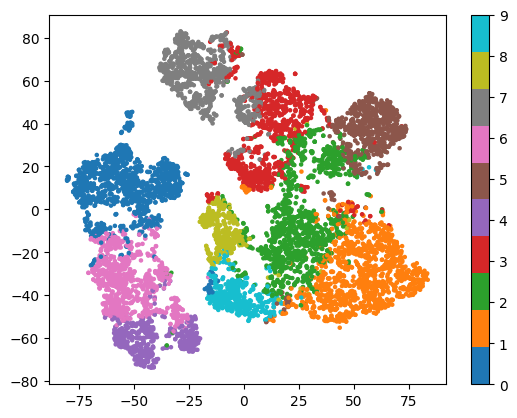

In [19]:
latents_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(all_latents)

fig, ax = plt.subplots()
scatter = ax.scatter(latents_tsne[:, 0], latents_tsne[:, 1], c=clusters_ids, s=5, cmap="tab10")
fig.colorbar(scatter)